In [1]:
!pip install -q keras-hub keras-cv tensorflow matplotlib numpy
!pip install --upgrade keras-hub
!pip install -q keras-hub keras-cv tensorflow matplotlib numpy
!pip install --upgrade keras-hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.7 MB/s eta 0:00:00
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import keras_cv
from keras_hub.models import Backbone, ViTImageClassifier


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train:", x_train.shape)
print("Test :", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


PART-1 — INFERENCE

CNN Inference — ResNet50 pretrained on ImageNet

In [4]:
cnn_imagenet = keras.applications.ResNet50(weights="imagenet")


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


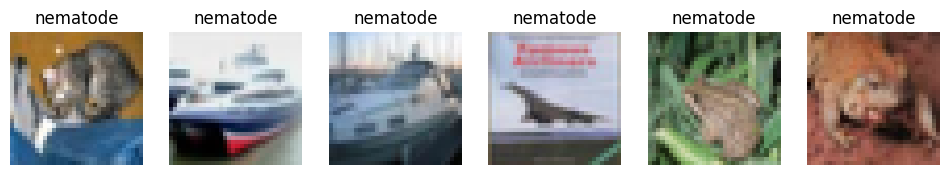

In [21]:
imgs = x_test[:6]
inp = tf.image.resize(imgs, (224,224))
pred = cnn_imagenet.predict(inp)
decoded = keras.applications.resnet.decode_predictions(pred, top=1)

plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(imgs[i])
    plt.title(decoded[i][0][1])
    plt.axis('off')
plt.show()


ViT Inference — Pretrained ImageNet ViT

In [6]:
vit_imagenet = ViTImageClassifier.from_preset("vit_base_patch16_224_imagenet")


100%|██████████| 698/698 [00:00<00:00, 1.69MB/s]


100%|██████████| 3.46k/3.46k [00:00<00:00, 7.14MB/s]


100%|██████████| 331M/331M [00:07<00:00, 49.0MB/s]


100%|██████████| 328M/328M [00:05<00:00, 61.7MB/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


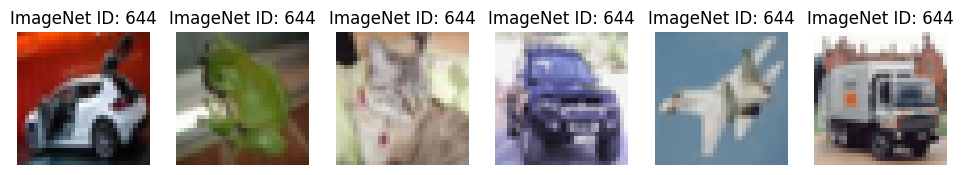

In [22]:
imgs = x_test[6:12]
inp = tf.image.resize(imgs, (224,224))
pred = vit_imagenet.predict(inp)
pred_ids = tf.argmax(pred, axis=1)

plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(imgs[i])
    plt.title("ImageNet ID: " + str(int(pred_ids[i])))
    plt.axis('off')
plt.show()


PART-2 — FINE-TUNING

Fine-tuning CNN on CIFAR-10

In [8]:
cnn = keras.Sequential([
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])


In [9]:
cnn.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4138 - loss: 1.6107 - val_accuracy: 0.6240 - val_loss: 1.0857
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6431 - loss: 1.0195 - val_accuracy: 0.6618 - val_loss: 0.9835
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7016 - loss: 0.8515 - val_accuracy: 0.6938 - val_loss: 0.8952
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7560 - loss: 0.7053 - val_accuracy: 0.6974 - val_loss: 0.8953
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8027 - loss: 0.5777 - val_accuracy: 0.7046 - val_loss: 0.8930
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8477 - loss: 0.4512 - val_accuracy: 0.7012 - val_loss: 0.9459
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8869 - loss: 0.3335 - val_accuracy: 0.6956 - val_loss: 1.0855
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9214 - loss: 0.2332 - val_accuracy: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


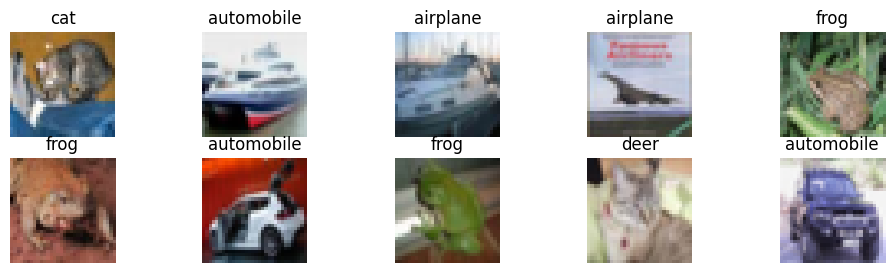

In [10]:
pred = np.argmax(cnn.predict(x_test[:10]), axis=1)

plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(class_names[pred[i]])
    plt.axis('off')
plt.show()


Fine-tuning ViT on CIFAR-10

In [11]:
vit_backbone = Backbone.from_preset("vit_base_patch16_224_imagenet")
vit_backbone.trainable = False


In [12]:
model = keras.Sequential([
    keras.layers.Resizing(224, 224),
    vit_backbone,
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(10, activation="softmax")
])


In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 570s 790ms/step - accuracy: 0.8318 - loss: 0.6131 - val_accuracy: 0.9212 - val_loss: 0.2406
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 543s 772ms/step - accuracy: 0.9280 - loss: 0.2299 - val_accuracy: 0.9310 - val_loss: 0.2032
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 545s 774ms/step - accuracy: 0.9363 - loss: 0.1944 - val_accuracy: 0.9342 - val_loss: 0.1901


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


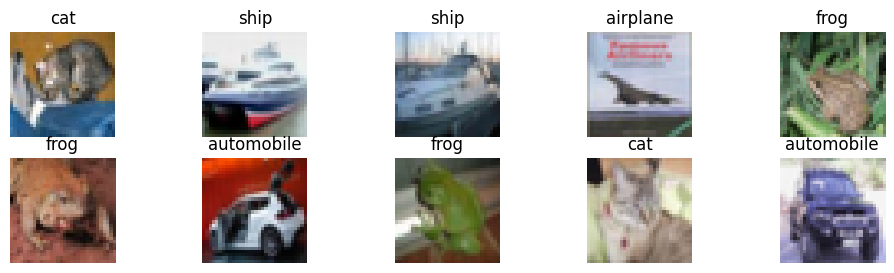

In [15]:
pred = np.argmax(model.predict(x_test[:10]), axis=1)

plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(class_names[pred[i]])   # CIFAR-10 labels
    plt.axis('off')
plt.show()
